# Hypothesis check

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from scipy.stats import rankdata
from pathlib import Path

BASE_DIR = Path.cwd().parent
file_path = BASE_DIR / "data" / "raw" / "student_lifestyle_dataset.csv"

df = pd.read_csv(file_path)



## - Hypothesis 1

### Students who sleep at least 7 hours per day have higher grades than students who sleep less.


CORRELATION WITHIN SLEEP GROUPS

< 7 hours (n=776):
  Pearson:  r=-0.0112, p=0.7563 Extremely minimal
  Spearman: ρ=-0.0080, p=0.8232 Extremely minimal

>= 7 hours (n=1224):
  Pearson:  r=-0.0403, p=0.1586 Extremely minimal
  Spearman: ρ=-0.0406, p=0.1559 Extremely minimal


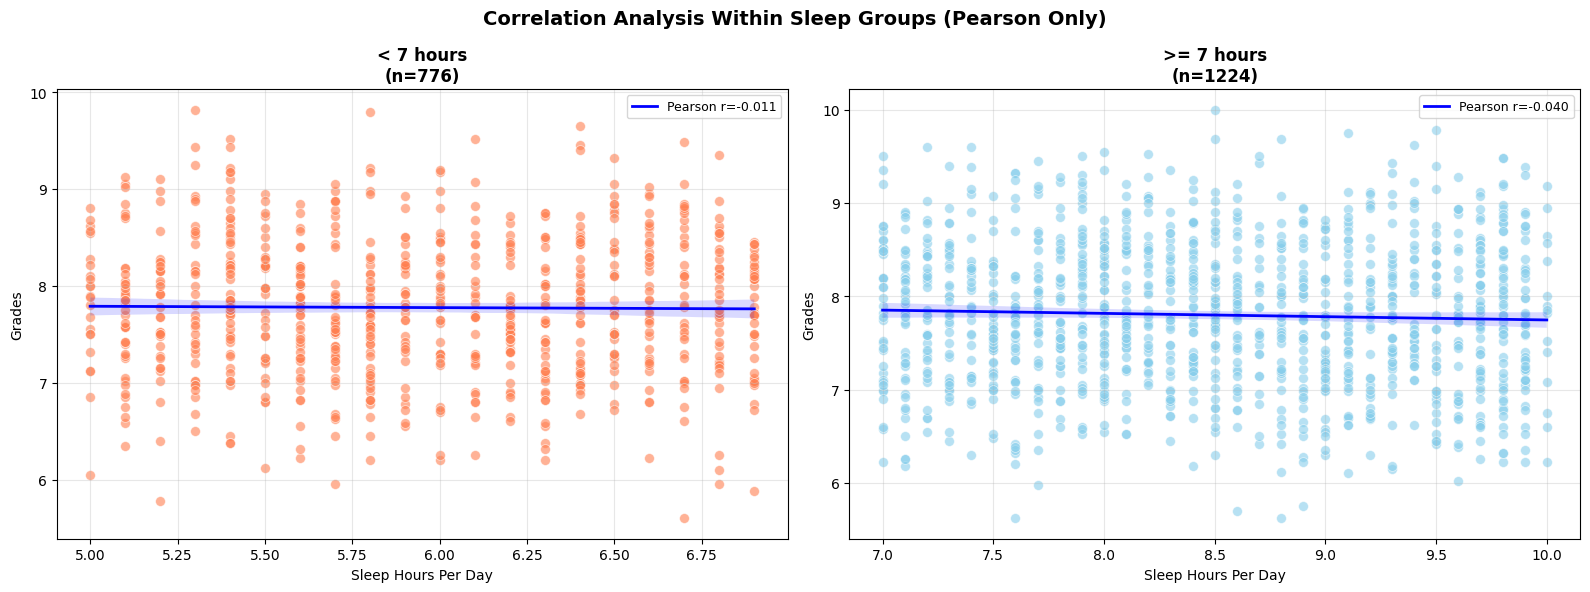

/var/folders/y9/zxqz5ct56s3177q3qysyh57m0000gn/T/ipykernel_12684/141501569.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


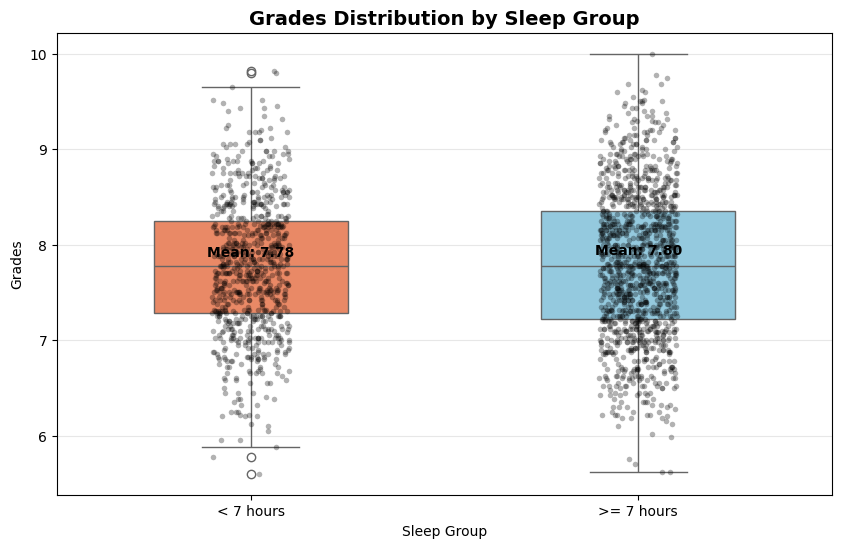

STATISTICAL COMPARISON: Sleep Groups (< 7 vs >= 7 hours)

Descriptive Statistics:
  Group < 7 hours:  n=776, Mean=7.776, Median=7.780, Std=0.710
  Group >= 7 hours: n=1224, Mean=7.799, Median=7.780, Std=0.769

1. Independent T-Test (compares MEANS):
   t-statistic = -0.678
   p-value = 0.4977
   Not significant at α = 0.05

2. Mann-Whitney U Test (compares DISTRIBUTIONS/MEDIANS):
   U-statistic = 467772.500
   p-value = 0.5705
   Not significant at α = 0.05

3. Consistency Check:
Both tests agree: no significant difference

Comparison Table:


,Test,What it compares,Statistic,P-value,Significant (α=0.05),Assumptions
0,T-Test,Means,t=-0.678,0.4977,No,"Normality, equal variance"
1,Mann-Whitney U,Distributions/Medians,U=467772.500,0.5705,No,No assumptions (non-parametric)


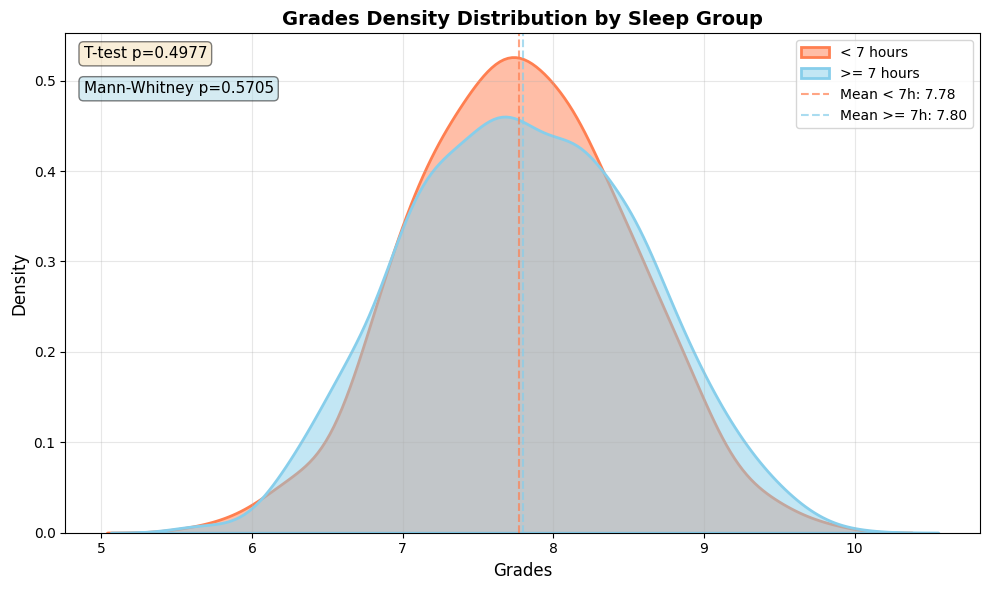

CONCLUSION: Hypothesis 1

1. Descriptive Statistics:
   Mean grade (< 7 hours):  7.776
   Mean grade (>= 7 hours): 7.799
   Difference: +0.023

2. Statistical Significance:
   T-test p-value:        0.4977
   Mann-Whitney p-value:  0.5705

3. Hypothesis Test Result:
HYPOTHESIS NOT SUPPORTED
   There is NO statistically significant difference in grades between sleep groups.
   The observed difference (+0.023) is likely due to random chance.

4. Practical Interpretation:
   The difference in mean grades is negligible (< 0.1 points).
   Even if statistically significant, it has no practical importance.


In [ ]:
sleep_col = "Sleep_Hours_Per_Day"
grades_col = "Grades"

def interpret_correlation(r):
    abs_r = abs(r)
    if abs_r < 0.1:
        return "Extremely minimal"
    elif abs_r < 0.3:
        return "Minimal"
    elif abs_r < 0.5:
        return "Moderate"
    elif abs_r < 0.7:
        return "Strong"
    else:
        return "Extremely Strong"


# Block 4: correlation inside groups

df['Sleep_Group'] = np.where(df[sleep_col] >= 7, '>= 7 hours', '< 7 hours')

print("CORRELATION WITHIN SLEEP GROUPS")

group_results = {}

for group in ['< 7 hours', '>= 7 hours']:
    subset = df[df['Sleep_Group'] == group]
    
    if len(subset) > 2:
        p_r, p_p = stats.pearsonr(subset[sleep_col], subset[grades_col])
        s_r, s_p = stats.spearmanr(subset[sleep_col], subset[grades_col])
        
        group_results[group] = {
            'pearson_r': p_r,
            'pearson_p': p_p,
            'spearman_r': s_r,
            'spearman_p': s_p,
            'n': len(subset)
        }
        
        print(f"\n{group} (n={len(subset)}):")
        print(f"  Pearson:  r={p_r:.4f}, p={p_p:.4f} {interpret_correlation(p_r)}")
        print(f"  Spearman: ρ={s_r:.4f}, p={s_p:.4f} {interpret_correlation(s_r)}")
    else:
        print(f"\n{group}: insufficient data for calculation\n")





# Block 5: scatter plots for each group

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'< 7 hours': 'coral', '>= 7 hours': 'skyblue'}

for idx, group in enumerate(['< 7 hours', '>= 7 hours']):
    subset = df[df['Sleep_Group'] == group]
    ax = axes[idx]
    
    sns.scatterplot(
        data=subset, 
        x=sleep_col, 
        y=grades_col, 
        alpha=0.6, 
        s=50,
        color=colors[group],
        ax=ax
    )
    
    if len(subset) > 2:
        sns.regplot(
            data=subset, 
            x=sleep_col, 
            y=grades_col, 
            scatter=False, 
            color='blue',
            line_kws={'linestyle': '-', 'linewidth': 2},
            ax=ax,
            label=f"Pearson r={group_results[group]['pearson_r']:.3f}"
        )
    
    ax.set_title(f"{group}\n(n={len(subset)})", fontsize=12, fontweight='bold')
    ax.set_xlabel("Sleep Hours Per Day")
    ax.set_ylabel("Grades")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Correlation Analysis Within Sleep Groups (Pearson Only)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()





# Block 6: comparison of grades between groups

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="Sleep_Group", 
    y=grades_col, 
    palette={'< 7 hours': 'coral', '>= 7 hours': 'skyblue'},
    width=0.5,
    order=['< 7 hours', '>= 7 hours']
)

sns.stripplot(
    data=df, 
    x="Sleep_Group", 
    y=grades_col, 
    color="black", 
    alpha=0.3, 
    jitter=True,
    size=4
)

means = df.groupby('Sleep_Group')[grades_col].mean()
for i, group in enumerate(['< 7 hours', '>= 7 hours']):
    plt.text(i, means[group] + 0.1, f'Mean: {means[group]:.2f}', 
             ha='center', fontsize=10, fontweight='bold')

plt.title("Grades Distribution by Sleep Group", fontsize=14, fontweight='bold')
plt.xlabel("Sleep Group")
plt.ylabel("Grades")
plt.grid(True, axis='y', alpha=0.3)
plt.show()





# Block 7: t-tests for difference in mean grades

group_less_7 = df[df['Sleep_Group'] == '< 7 hours'][grades_col]
group_7_plus = df[df['Sleep_Group'] == '>= 7 hours'][grades_col]


t_stat, p_val_t = stats.ttest_ind(group_less_7, group_7_plus, equal_var=False)


u_stat, p_val_mw = stats.mannwhitneyu(group_less_7, group_7_plus, alternative='two-sided')


print("STATISTICAL COMPARISON: Sleep Groups (< 7 vs >= 7 hours)")

print("\nDescriptive Statistics:")
print(f"  Group < 7 hours:  n={len(group_less_7)}, Mean={group_less_7.mean():.3f}, Median={group_less_7.median():.3f}, Std={group_less_7.std():.3f}")
print(f"  Group >= 7 hours: n={len(group_7_plus)}, Mean={group_7_plus.mean():.3f}, Median={group_7_plus.median():.3f}, Std={group_7_plus.std():.3f}")

print("\n1. Independent T-Test (compares MEANS):")
print(f"   t-statistic = {t_stat:.3f}")
print(f"   p-value = {p_val_t:.4f}")
print(f"   {'Significant' if p_val_t < 0.05 else 'Not significant'} at α = 0.05")

print("\n2. Mann-Whitney U Test (compares DISTRIBUTIONS/MEDIANS):")
print(f"   U-statistic = {u_stat:.3f}")
print(f"   p-value = {p_val_mw:.4f}")
print(f"   {'Significant' if p_val_mw < 0.05 else 'Not significant'} at α = 0.05")

print("\n3. Consistency Check:")
if (p_val_t < 0.05) == (p_val_mw < 0.05):
    print(f"Both tests agree: {'significant difference' if p_val_t < 0.05 else 'no significant difference'}")
else:
    print("Tests disagree (possible non-normal distribution or outliers)")

comparison_results = pd.DataFrame({
    'Test': ['T-Test', 'Mann-Whitney U'],
    'What it compares': ['Means', 'Distributions/Medians'],
    'Statistic': [f't={t_stat:.3f}', f'U={u_stat:.3f}'],
    'P-value': [f'{p_val_t:.4f}', f'{p_val_mw:.4f}'],
    'Significant (α=0.05)': ['Yes' if p_val_t < 0.05 else 'No', 'Yes' if p_val_mw < 0.05 else 'No'],
    'Assumptions': ['Normality, equal variance', 'No assumptions (non-parametric)']
})

print("\nComparison Table:")
display(comparison_results)


plt.figure(figsize=(10, 6))


sns.kdeplot(
    data=df[df['Sleep_Group'] == '< 7 hours'][grades_col],
    label='< 7 hours',
    color='coral',
    fill=True,
    alpha=0.5,
    linewidth=2
)


sns.kdeplot(
    data=df[df['Sleep_Group'] == '>= 7 hours'][grades_col],
    label='>= 7 hours',
    color='skyblue',
    fill=True,
    alpha=0.5,
    linewidth=2
)


mean_less_7 = df[df['Sleep_Group'] == '< 7 hours'][grades_col].mean()
mean_7_plus = df[df['Sleep_Group'] == '>= 7 hours'][grades_col].mean()

plt.axvline(x=mean_less_7, color='coral', linestyle='--', linewidth=1.5, 
            alpha=0.7, label=f'Mean < 7h: {mean_less_7:.2f}')
plt.axvline(x=mean_7_plus, color='skyblue', linestyle='--', linewidth=1.5, 
            alpha=0.7, label=f'Mean >= 7h: {mean_7_plus:.2f}')


plt.text(0.02, 0.95, f'T-test p={p_val_t:.4f}', 
         transform=plt.gca().transAxes, fontsize=11, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'Mann-Whitney p={p_val_mw:.4f}', 
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.title("Grades Density Distribution by Sleep Group", fontsize=14, fontweight='bold')
plt.xlabel("Grades", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()





# Block 9: Conclusion

print("CONCLUSION: Hypothesis 1")

print("\n1. Descriptive Statistics:")
print(f"   Mean grade (< 7 hours):  {mean_less_7:.3f}")
print(f"   Mean grade (>= 7 hours): {mean_7_plus:.3f}")
print(f"   Difference: {mean_7_plus - mean_less_7:+.3f}")

print("\n2. Statistical Significance:")
print(f"   T-test p-value:        {p_val_t:.4f}")
print(f"   Mann-Whitney p-value:  {p_val_mw:.4f}")

print("\n3. Hypothesis Test Result:")

if p_val_t < 0.05 and p_val_mw < 0.05:
    if mean_7_plus > mean_less_7:
        print("HYPOTHESIS CONFIRMED")
        print("   Students who sleep >= 7 hours have SIGNIFICANTLY higher grades.")
    else:
        print("HYPOTHESIS REJECTED (opposite effect)")
        print("   Students who sleep >= 7 hours have SIGNIFICANTLY LOWER grades.")
elif p_val_t >= 0.05 and p_val_mw >= 0.05:
    print("HYPOTHESIS NOT SUPPORTED")
    print("   There is NO statistically significant difference in grades between sleep groups.")
    print(f"   The observed difference ({mean_7_plus - mean_less_7:+.3f}) is likely due to random chance.")
else:
    print("INCONCLUSIVE")
    print("   Statistical tests provide conflicting results.")
    print("   Further investigation needed (check for outliers, non-normality).")

print("\n4. Practical Interpretation:")
if abs(mean_7_plus - mean_less_7) < 0.1:
    print("   The difference in mean grades is negligible (< 0.1 points).")
    print("   Even if statistically significant, it has no practical importance.")
elif abs(mean_7_plus - mean_less_7) < 0.3:
    print("   The difference is small but may be practically relevant.")
else:
    print("   The difference is substantial and practically meaningful.")

## Hypothesis 1: Students who sleep at least 7 hours per day have higher grades than students who sleep less

### 1.Hypothesis Statement
**H₁**: Students who sleep ≥ 7 hours per day have higher grades than students who sleep < 7 hours.
**H₀** (Null): There is no difference in grades between students who sleep ≥ 7 hours and those who sleep < 7 hours.

### 2. Methodology

**Data Preparation**:
- Created binary categorical variable Sleep_Group:
    - < 7 hours: n = 776 students (38.8%)
    - ≥ 7 hours: n = 1224 students (61.2%)

**Statistical Tests**:
- Independent T-Test (Welch's t-test): Compares means between two independent groups; assumes normality
- Mann-Whitney U Test: Non-parametric alternative; compares distributions/medians; no distributional assumptions

**Significance Level**: α = 0.05

### 3. Descriptive Statistics

| Group | n | Mean | Median | Std |
|-------|---|------|--------|-----|
| < 7 hours | 776 | 7.776 | 7.780 | 0.710 |
| < 7 hours | 1224 | 7.799 | 7.780 | 0.769 |
| Difference | - | +0.023 | 0.000 | - |

**Key Observations**:
- Mean grades are nearly identical (difference = +0.023 points)
- Medians are exactly the same (7.780)
- Standard deviations are similar (0.710 vs 0.769)

### 4. Visual Analysis

**4.1 Correlation Within Sleep Groups**

Findings:
- < 7 hours group: Pearson r = -0.011 (p = 0.756), Spearman ρ = -0.008 (p = 0.823)
- ≥ 7 hours group: Pearson r = -0.040 (p = 0.159), Spearman ρ = -0.041 (p = 0.156)
- Both groups show extremely minimal correlation between sleep hours and grades
- Regression lines are nearly horizontal, indicating no linear relationship within either group

**4.2 Boxplot Comparison**

Findings:
- Boxplots show nearly identical distributions
- Medians (black lines inside boxes) are at the same level
- Interquartile ranges overlap substantially
- Outliers present in both groups but not concentrated in either

**4.3 Density Distribution (KDE)**

Findings:
- KDE curves for both groups are nearly identical in shape and position
- Peak density occurs at the same grade value (~7.8)
- Distribution spread is similar
- Visual overlap confirms no meaningful difference

### 5. Statistical Test Results

| Test | Compararison on | Statistic | P-value | is α>=0.05? (critical) | Assumptions
|------|-----------------|-----------|---------|------------------------|------------|
| T-Test | Means | t = -0.678 | 0.4977 | No | Normality, equal variance |
| Mann-Whitney | Distributions/Medians | U = 467772.500 | 0.5705 | No | Non-parametric |

### 6. Hypothesis Test Result

**HYPOTHESIS NOT SUPPORTED**

Statistical Evidence:
- T-test p-value: 0.4977 (>> 0.05)
- Mann-Whitney p-value: 0.5705 (>> 0.05)
- Both tests fail to reject the null hypothesis

Interpretation:
There is no statistically significant difference in grades between students who sleep < 7 hours and those who sleep ≥ 7 hours. The observed difference (+0.023 points) is negligible and likely due to random chance.

### 7. Practical Interpretation

Effect Size Assessment:
- Mean difference: +0.023 points (on a scale of ~5.6 to 10)
- This represents a 0.23% difference — practically meaningless
- Even if this difference were statistically significant (which it is not), it would have no educational or practical importance

Correlation Analysis:
- Within-group correlations are extremely minimal (|r| < 0.05)
- Sleep hours do not predict grades within either group
- The relationship between sleep and grades appears to be non-existent in this dataset

### 8. Possible Explanations

Effect Size Assessment:
1. **Synthetic Data Artifact**: The dataset may have been generated without a sleep-grades relationship
2. **Confounding Variables**: Other factors (e.g., Study Hours, which shows r = 0.734 with Grades) may dominate the relationship
3. **Threshold Effect**: The 7-hour threshold may not be the right cutoff; the relationship might be non-linear
4. **Measurement Issues**: Self-reported sleep hours may not accurately reflect actual sleep quality or duration

### 9. Conclusion

**Final Verdict**: The hypothesis that students who sleep at least 7 hours per day have higher grades is not supported by the data.

Key Findings:
- No statistically significant difference in mean grades (p = 0.498)
- No difference in grade distributions (Mann-Whitney p = 0.571)
- Negligible effect size (+0.023 points)
- No correlation between sleep hours and grades within either group

**Recommendation**: In this dataset, sleep duration does not appear to be a predictor of academic performance. Further analysis should focus on stronger predictors like Study Hours (r = 0.734) or investigate potential interaction effects between multiple lifestyle factors.


## - Hypothesis 2

### Students with more sleep hours per day tend to have higher grades.

CORRELATION ANALYSIS: Sleep Hours vs Grades


Pearson Correlation:
  r = -0.0043
  p-value = 0.8491
  Strength: Extremely minimal

Spearman Correlation:
  ρ (rho) = -0.0062
  p-value = 0.7807
  Strength: Extremely minimal

Interpretation:
  Pearson: Extremely minimal (negative)
  Spearman: Extremely minimal (negative)



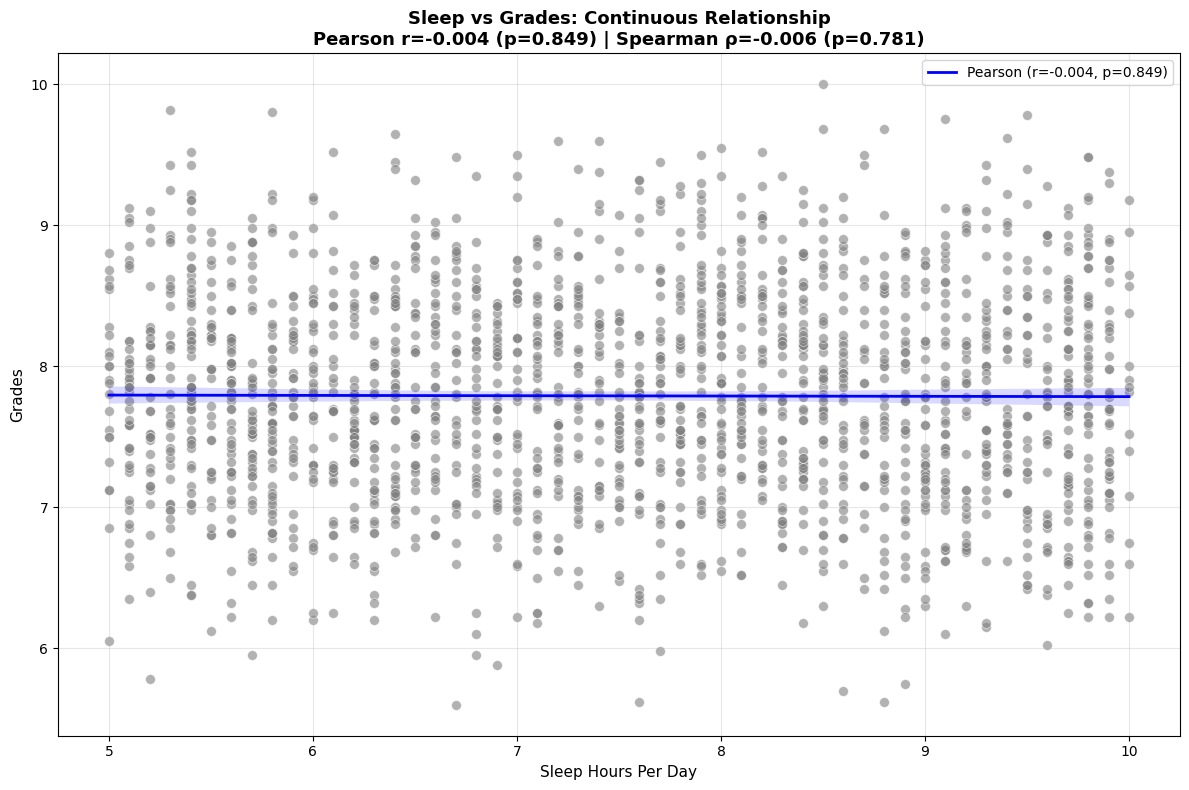


Comparative table:


,Metric,Pearson,Spearman
0,Correlation Coefficient,-0.0043,-0.0062
1,P-value,0.8491,0.7807
2,Significant (α=0.05)?,No,No
3,Strength,Extremely minimal,Extremely minimal
4,Direction,Negative,Negative


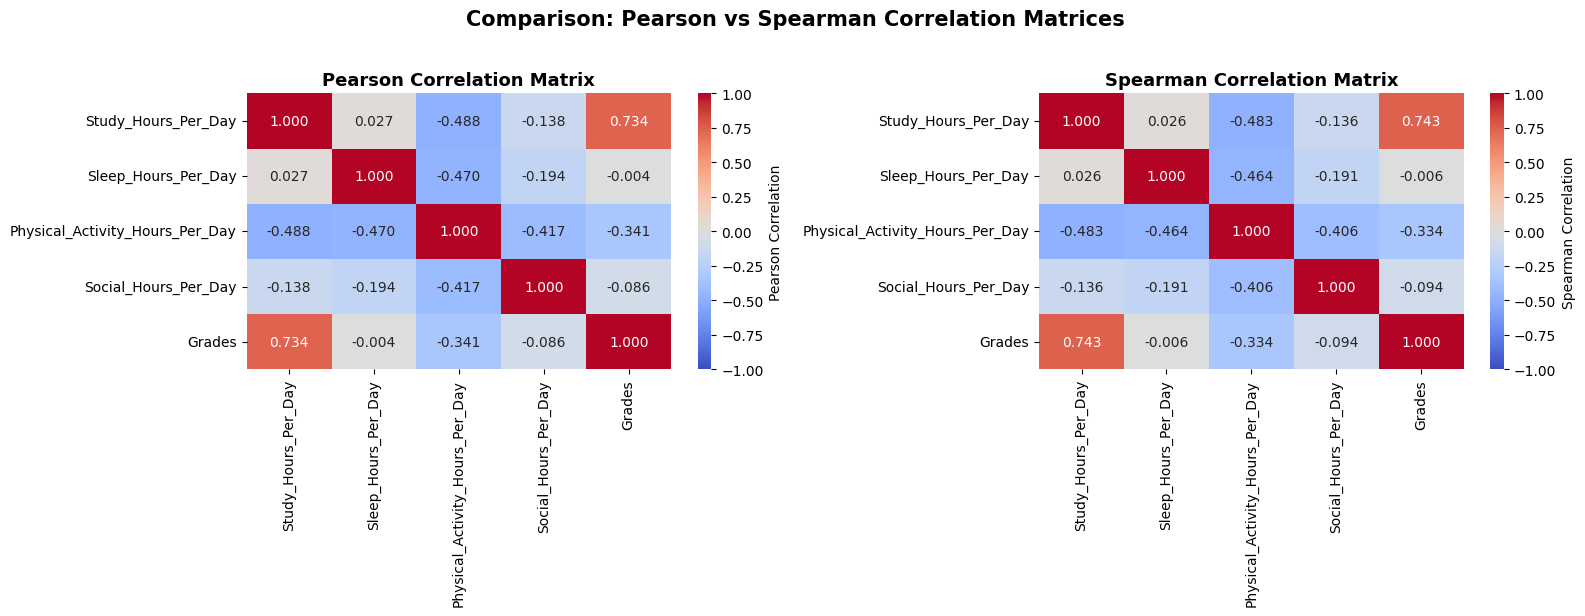


Conclusion


1. General correlation:
   Pearson: r=-0.0043 (p=0.8491) - Extremely minimal
   Spearman: ρ=-0.0062 (p=0.7807) - Extremely minimal

2. Coherence of methods:
Both methods give the same conclusion about the significance

3. Overall finding:
There is NO statistically significant correlation between sleep and grades
Sleep hours do not appear to be related to grades in this dataset


In [ ]:
# Block 1: Global correlation analysis

pearson_r, pearson_p = stats.pearsonr(df[sleep_col], df[grades_col])
spearman_r, spearman_p = stats.spearmanr(df[sleep_col], df[grades_col])

print("CORRELATION ANALYSIS: Sleep Hours vs Grades\n")
print("\nPearson Correlation:")
print(f"  r = {pearson_r:.4f}")
print(f"  p-value = {pearson_p:.4f}")
print(f"  Strength: {interpret_correlation(pearson_r)}")

print("\nSpearman Correlation:")
print(f"  ρ (rho) = {spearman_r:.4f}")
print(f"  p-value = {spearman_p:.4f}")
print(f"  Strength: {interpret_correlation(spearman_r)}")

print("\nInterpretation:")
print(f"  Pearson: {interpret_correlation(pearson_r)} ({'positive' if pearson_r > 0 else 'negative'})")
print(f"  Spearman: {interpret_correlation(spearman_r)} ({'positive' if spearman_r > 0 else 'negative'})\n")





# Block 2: Scatterplot with regression line

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df, 
    x=sleep_col, 
    y=grades_col, 
    alpha=0.6, 
    s=50,
    color='gray'
)

sns.regplot(
    data=df, 
    x=sleep_col, 
    y=grades_col, 
    scatter=False, 
    color='blue',
    line_kws={'linestyle': '-', 'linewidth': 2},
    label=f'Pearson (r={pearson_r:.3f}, p={pearson_p:.3f})'
)

plt.title(f"Sleep vs Grades: Continuous Relationship\n"
          f"Pearson r={pearson_r:.3f} (p={pearson_p:.3f}) | Spearman ρ={spearman_r:.3f} (p={spearman_p:.3f})",
          fontsize=13, fontweight='bold')
plt.xlabel("Sleep Hours Per Day", fontsize=11)
plt.ylabel("Grades", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()





# Block 3: Comparative correlation table

comparison_df = pd.DataFrame({
    'Metric': ['Correlation Coefficient', 'P-value', 'Significant (α=0.05)?', 
               'Strength', 'Direction'],
    'Pearson': [
        f'{pearson_r:.4f}',
        f'{pearson_p:.4f}',
        'Yes' if pearson_p < 0.05 else 'No',
        interpret_correlation(pearson_r),
        'Positive' if pearson_r > 0 else 'Negative'
    ],
    'Spearman': [
        f'{spearman_r:.4f}',
        f'{spearman_p:.4f}',
        'Yes' if spearman_p < 0.05 else 'No',
        interpret_correlation(spearman_r),
        'Positive' if spearman_r > 0 else 'Negative'
    ]
})

print("\nComparative table:")
display(comparison_df)





# Block 8: correlations matrices for pearson and spearman

numeric_cols = [
    "Study_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Grades"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pearson_corr = df[numeric_cols].corr(method='pearson')
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[0], fmt='.3f', 
            cbar_kws={'label': 'Pearson Correlation'})
axes[0].set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold')

spearman_corr = df[numeric_cols].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[1], fmt='.3f',
            cbar_kws={'label': 'Spearman Correlation'})
axes[1].set_title('Spearman Correlation Matrix', fontsize=13, fontweight='bold')

plt.suptitle('Comparison: Pearson vs Spearman Correlation Matrices', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()





# Block 9: Conclusion

print("\nConclusion\n")

print("\n1. General correlation:")
print(f"   Pearson: r={pearson_r:.4f} (p={pearson_p:.4f}) - {interpret_correlation(pearson_r)}")
print(f"   Spearman: ρ={spearman_r:.4f} (p={spearman_p:.4f}) - {interpret_correlation(spearman_r)}")

print("\n2. Coherence of methods:")
if (pearson_p < 0.05) == (spearman_p < 0.05):
    print("Both methods give the same conclusion about the significance")
else:
    print("The methods yield different conclusions (non-linear relationships are possible)")

print("\n3. Overall finding:")
if pearson_p < 0.05 and pearson_r > 0:
    print("There is a statistically significant POSITIVE correlation between sleep and grades")
    print("Students with more sleep tend to have higher grades")
elif pearson_p < 0.05 and pearson_r < 0:
    print("There is a statistically significant NEGATIVE correlation between sleep and grades")
    print("Students with more sleep tend to have LOWER grades")
else:
    print("There is NO statistically significant correlation between sleep and grades")
    print("Sleep hours do not appear to be related to grades in this dataset")